In [ ]:
#CHURN BANK CUSTOMER ANALYSIS
#Customer churn is one of the most critical challenges facing financial institutions. When customers close their accounts or stop using banking services, it directly impacts revenue, profitability, and long-term business growth.

#This project analyzes the Bank Customer Churn Dataset to understand the key factors influencing customer attrition. By exploring customer demographics, account information, and behavioral patterns, we aim to identify trends and risk indicators associated with churn.

#Through Exploratory Data Analysis (EDA), this study will:

#Examine the distribution of customer characteristics

#Identify patterns between churned and retained customers

#Detect correlations among key variables

#Highlight potential drivers of customer exit

#The insights generated from this analysis can help banks develop proactive retention strategies, improve customer satisfaction, and reduce revenue loss.

In [1]:
pip install pandas matplotlib seaborn openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   ---------------------------------------- 2/2 [openpyxl]

Note: you may need to restart the kernel to use updated packages.


In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#For better visuals
sns.set(style="whitegrid")
%matplotlib inline

In [101]:
import warnings
warnings.simplefilter("ignore")

In [102]:
from IPython import get_ipython
%reset -sf

In [106]:
import pandas as pd
file_path = 'Churn_Modelling_edited.csv'
df = pd.read_csv(file_path)

In [107]:
print("Data Overview:")
print(df.info())

Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Row_Number          10000 non-null  int64 
 1   Customer_Id         10000 non-null  int64 
 2   Surname             10000 non-null  object
 3   Credit_Score        10000 non-null  int64 
 4   Geography           10000 non-null  object
 5   Gender              10000 non-null  object
 6   Age                 10000 non-null  int64 
 7   Tenure              10000 non-null  int64 
 8   Balance             10000 non-null  object
 9   NumOfProducts       10000 non-null  int64 
 10  HasCr_Card          10000 non-null  int64 
 11  Active_Member       10000 non-null  int64 
 12   Estimated_Salary   10000 non-null  object
 13  Exited              10000 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 1.1+ MB
None


In [111]:
# Clean Coulmn Names (removing hidden spaces)
df.columns = df.columns.str.strip()

In [112]:
# We need to convert '$1,000.00' strings to float numbers
def clean_currency(value):
    if isinstance(value, str):
        return float(value.replace('$','').replace(',','').strip())
    return value
                     

In [113]:
df['Balance'] = df['Balance'].apply(clean_currency)
df['Estimated_Salary'] = df['Estimated_Salary'].apply(clean_currency)

In [114]:
#Handle Missing values
df.dropna(inplace=True)

In [116]:
#Remove irrelevant ID columns for analysis
churn_df = df.drop(['Row_Number','Customer_Id', 'Surname'], axis=1)

In [117]:
churn_df.head()

,Credit_Score,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCr_Card,Active_Member,Estimated_Salary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [118]:
print( "\nBasic Statistical Summary:")
display(churn_df.describe())


Basic Statistical Summary:


,Credit_Score,Age,Tenure,Balance,NumOfProducts,HasCr_Card,Active_Member,Estimated_Salary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#For better visuals
sns.set(style="whitegrid")
%matplotlib inline

In [125]:
#Lets create a figure for multiple plots
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Text(0.5, 1.0, 'Distribution of Customer Age')

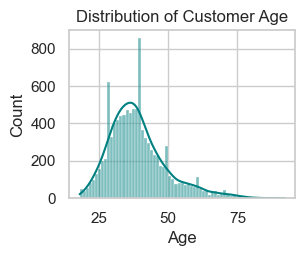

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

#Distribution of Age
#What age group dominates the customer base?
plt.subplot(2,2,1)
sns.histplot(df['Age'], kde=True, color='teal')
plt.title('Distribution of Customer Age')

Text(0.5, 1.0, 'Churn Count by Geography')

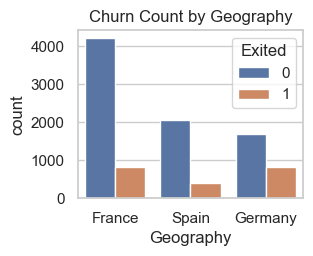

In [152]:
#Churn by Geography
#Business Question answered:
#Which country has the highest churn

plt.subplot(2,2,2)
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title('Churn Count by Geography')

Text(0.5, 1.0, 'Feature Correlation Heatmap')

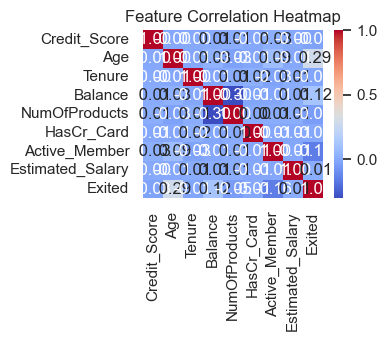

In [153]:
#Correlation HeatMap
#Which variables strongly influenece churn
plt.subplot(2,2,3)
numeric_df = analysis_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=' .2f')
plt.title('Feature Correlation Heatmap')


Text(0.5, 1.0, 'Age Range of Churned vs Active Customers')

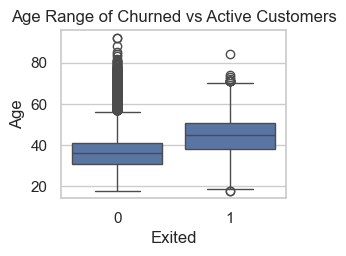

In [154]:
#Age vs Churn(Boxplot)
#Business Question Answered:
#Are churned customers older than active customers
plt.subplot(2,2,4)
sns.boxplot(x='Exited', y='Age', data=df)
plt.title('Age Range of Churned vs Active Customers')

In [138]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [140]:
#Overall Churn Rate
print(f'Overall Churn Rate: {df['Exited'].mean()*100:2f}%')

Overall Churn Rate: 20.370000%


In [141]:
#Churn by Age Group
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,30,45,60,100],
                        labels=['Young','Middle-Aged','Senior','Elderly'])
print("\n2. Churn Rate by Age Group:\n", df.groupby('AgeGroup', observed=False)['Exited'].mean()* 100)


2. Churn Rate by Age Group:
 AgeGroup
Young           7.520325
Middle-Aged    15.740584
Senior         51.123254
Elderly        24.784483
Name: Exited, dtype: float64


In [142]:
#High Balance Churn (Balance > 100k)
hb_churn = df[df['Balance'] > 100000]['Exited'].mean() * 100
print(f'\n3. Churn rate for customers with >100k Balance: {hb_churn:.2f}%')



3. Churn rate for customers with >100k Balance: 25.23%


In [144]:
#Impact of credit card
print('\n4. Churn Rate by Credit Card Possession:\n', df.groupby('HasCr_Card')['Exited'].mean()*100)


4. Churn Rate by Credit Card Possession:
 HasCr_Card
0    20.814941
1    20.184266
Name: Exited, dtype: float64


In [145]:
#Geography with Highest Churn
geo_risk = df.groupby('Geography')['Exited'].mean().idxmax()
print(f"\n5. Country with the highest churn risk: {geo_risk}")


5. Country with the highest churn risk: Germany


In [146]:
#Active vs Inactive Churn

print('\n6. Churn Rate:: Active(1) vs Inactive(0):\n', df.groupby('Active_Member')['Exited'].mean() *100)



6. Churn Rate:: Active(1) vs Inactive(0):
 Active_Member
0    26.850897
1    14.269074
Name: Exited, dtype: float64


In [147]:
#Gender Churn Rate
print("\n7. Churn Rate by Gender:\n", df.groupby('Gender')['Exited'].mean() * 100)


7. Churn Rate by Gender:
 Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


In [148]:
#Impact of Number of Products
print("\n8. Churn Rate by Number of Products:\n", df.groupby('NumOfProducts')['Exited'].mean() * 100)


8. Churn Rate by Number of Products:
 NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64


In [149]:
#Average Credit Score of Churners
avg_cs = df[df['Exited']==1]['Credit_Score'].mean()
print(f"\n9. Average Credit Score of customers who left: {avg_cs:.2f}")


9. Average Credit Score of customers who left: 645.35


In [155]:
#Total Balance Lost to Churn
total_lost = df[df['Exited'] ==1]['Balance'].sum()
print(f'\n10.Total Balance Lost to Churn: ${total_lost:,.2f}')


10.Total Balance Lost to Churn: $185,588,094.63


In [ ]:
#A total of $185,588,094.63 was lost to Churn. Crazy!